OR Gate

In [1]:
import numpy as np

x = np.array([[0,0],[0,1],[1,0],[1,1]])  # in this array each index represent the value of x1 and x2
y = np.array([0,1,1,1]) # true output

w = np.linspace(0,1,2) # assume w1 = 0.5 and w2 = 0.5
b = 0 # assume bias 0
alpha = 1 # learning rate is 1

def step(z):     # activation function or step function
  if(z>=0):
    return 1
  else:
    return 0

#training
for epoch in range(100):
  for i in range(len(x)):
    z = np.dot(x[i],w) + b  # here z = w*x + b
    y_pred = step(z)        # using step function
    error = y[i] - y_pred   # calculate the error

    w = w + alpha * error * x[i]  # update weight
    b = b + alpha * error # update bias


print('Weights : ',w) # final weights
print('Bias : ', b)   # final bias

Weights :  [1. 1.]
Bias :  -1


In [2]:
# testing
for i in range(len(x)):

    z = np.dot(x[i],w) + b
    print('predicted output for ',x[i],' is ', step(z))

predicted output for  [0 0]  is  0
predicted output for  [0 1]  is  1
predicted output for  [1 0]  is  1
predicted output for  [1 1]  is  1


Single Layer Perceptron on Iris Dataset

In [3]:
class Perceptron:
  def __init__(self,lr = 0.01,epochs = 100):
    self.lr = lr
    self.epochs = epochs

  @staticmethod
  def step(z):     # activation function or step function
      if(z>=0):
       return 1
      else:
       return 0

  def train(self,x,y):
    self.weights = np.zeros(x.shape[1])
    self.bias = 0

    for e in range(self.epochs):
      for i in range(len(x)):
        z = np.dot(x[i],self.weights) + self.bias
        y_pred = Perceptron.step(z)

        error = y[i] - y_pred

        self.weights = self.weights + self.lr * error * x[i]
        self.bias = self.bias + self.lr * error

  def prediction(self,x):
    z = np.dot(x,self.weights) + self.bias
    return np.where(z>=0,1,0)

  def accuracy(self,x_test,y_test):
    predictions = self.prediction(x_test)

    accuracy = np.sum(predictions == y_test)/len(y_test)
    print(accuracy)

In [5]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets

# metadata
print(iris.metadata)

# variable information
print(iris.variables)

{'uci_id': 53, 'name': 'Iris', 'repository_url': 'https://archive.ics.uci.edu/dataset/53/iris', 'data_url': 'https://archive.ics.uci.edu/static/public/53/data.csv', 'abstract': 'A small classic dataset from Fisher, 1936. One of the earliest known datasets used for evaluating classification methods.\n', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 150, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1936, 'last_updated': 'Tue Sep 12 2023', 'dataset_doi': '10.24432/C56C76', 'creators': ['R. A. Fisher'], 'intro_paper': {'ID': 191, 'type': 'NATIVE', 'title': 'The Iris data set: In search of the source of virginica', 'authors': 'A. Unwin, K. Kleinman', 'venue': 'Significance, 2021', 'year': 2021, 'journal': 'Significance, 2021', 'DOI': '1740-9713.01589', 'URL': 'https://www.semanticscholar.org

In [ ]:
X.head()

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
y.head()

,class
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa


In [6]:
import pandas as pd
import numpy as np

iris_data = pd.concat([X,y],axis = 1)

In [7]:
iris_data.shape

(150, 5)

In [8]:
iris_data.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [9]:
a = iris_data.iloc[:,:-3]
b = iris_data.iloc[:,-1]

mask = b != 'Iris-virginica'

a_filtered = a[mask]
b_filtered = b[mask]

In [10]:
a_filtered.shape

(100, 2)

In [11]:
b_filtered.shape

(100,)

In [12]:
from sklearn.model_selection import train_test_split

# Map string labels to numerical values
label_mapping = {'Iris-setosa': 0, 'Iris-versicolor': 1}
b_encoded = b_filtered.map(label_mapping)

x_train,x_test,y_train,y_test = train_test_split(a_filtered.values,b_encoded.values,test_size = 0.2,random_state = 5)

In [13]:
iris_model = Perceptron(lr = 0.01, epochs=1000)
iris_model.train(x_train,y_train)
iris_model.accuracy(x_test,y_test)

1.0


In [14]:
test1 = [1.8,0.6]
output = iris_model.prediction(test1)
if(output == 0):
  print('Iris-setosa')
elif(output == 1):
  print('Iris-versicolor')

Iris-setosa


In [15]:
test2 = [3,0.9]
output = iris_model.prediction(test2)
if(output == 0):
  print('Iris-setosa')
elif(output == 1):
  print('Iris-versicolor')

Iris-versicolor


Text(0.5, 1.0, 'Petal width vs Petal length')

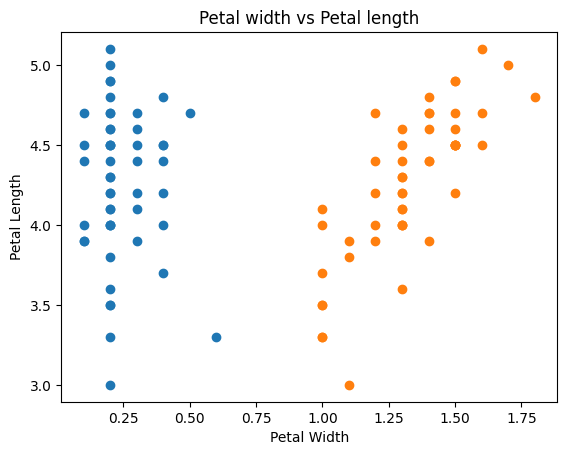

In [16]:
import matplotlib.pyplot as plt

setosa = iris_data[iris_data['class'] == 'Iris-setosa']
versicolor = iris_data[iris_data['class'] == 'Iris-versicolor']

plt.scatter(setosa['petal width'],versicolor['petal length'],label = 'Iris setosa')
plt.scatter(versicolor['petal width'],versicolor['petal length'], label = 'Iris versicolor')
plt.xlabel('Petal Width')
plt.ylabel('Petal Length')
plt.title('Petal width vs Petal length')